# Global vs Local Calibration by Case of the Multi-Curve MHW Model

This notebook performs the calibration of the Multi-Curve Markovian Hull-White (MHW) model separately for each market configuration.

The calibration is carried out across:
- two market dates, corresponding to the 2022 and 2023 datasets;
- three fixed values of the correlation parameter $\gamma \in ({0, 0.5, 1})$;
- the diagonal swaption instruments required by the assignment.

The main goal is to estimate the parameters $a$ and $b$ by minimizing the discrepancy between market swaption prices and model-implied prices.

### Data Loading and Setup

The notebook first loads the multi-curve market data exported from MATLAB.

For each reference case, the following inputs are imported:
- the OIS discounting curve;
- the EURIBOR 3M forwarding curve;
- the diagonal swaption market dataset.

These inputs are then used consistently throughout the objective-landscape analysis, the global calibration, and the local benchmark.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd

from mhw_utilities import load_curve_from_csv

data_dir = Path("python_exports")

ois22 = load_curve_from_csv(data_dir / "curve_2022_ois.csv", "2022-06-28")
eur22 = load_curve_from_csv(data_dir / "curve_2022_eur3m.csv", "2022-06-28")
ois23 = load_curve_from_csv(data_dir / "curve_2023_ois.csv", "2023-02-02")
eur23 = load_curve_from_csv(data_dir / "curve_2023_eur3m.csv", "2023-02-02")

mkt22 = pd.read_csv(data_dir / "diag_market_2022.csv")
mkt23 = pd.read_csv(data_dir / "diag_market_2023.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Objective Function Landscape Analysis

As a preliminary diagnostic step, the calibration objective function is evaluated on a coarse grid of $(a,b)$ values.

For each year and each fixed value of $\gamma$, the Sum of Squared Errors (SSE) between market prices and model prices is computed over a broad parameter region.

This analysis is useful to:
- inspect the overall shape of the calibration error surface;
- identify regions associated with low pricing errors;
- detect possible flat areas or multiple local minima;
- select reasonable bounds for the subsequent optimization stage.

In [3]:
import time
import numpy as np
from mhw_calibration import plot_mhw_ab_objective_landscape

grid_points = 20
a_vals = np.linspace(0.0, 1, grid_points)
b_vals = np.linspace(0.0, 1, grid_points)

# Mappa dati per anno
data_by_year = {
    2022: (ois22, eur22, mkt22),
    2023: (ois23, eur23, mkt23),
}

gammas = [0.0, 0.5, 1.0]
all_results = {}

for year in [2022, 2023]:
    ois_plot, eur_plot, mkt_plot = data_by_year[year]

    for gamma in gammas:
        start = time.perf_counter()

        grid_data = plot_mhw_ab_objective_landscape(
            ois_curve=ois_plot,
            eur3m_curve=eur_plot,
            diag_summary_df=mkt_plot,
            gamma=gamma,
            is_payer=True,
            is_cs=True,
            a_values=a_vals,
            b_values=b_vals,
            interactive=True,
        )

        elapsed = time.perf_counter() - start
        min_point = grid_data["min_point"]

        key = (year, gamma)
        all_results[key] = {
            "elapsed_s": elapsed,
            "min_point": min_point,
            "grid_data": grid_data,
        }


### Global Calibration 

The robust global calibration is  performed for all market cases.

For each year and each fixed value of $\gamma \in ({0, 0.5, 1})$, the parameters $a$ and %b% are estimated by minimizing the SSE between market swaption prices and model prices.

The procedure combines:
- a global Differential Evolution search over the admissible parameter bounds;
- local refinement using the best candidate solutions;
- instrument-level pricing error storage;
- aggregate calibration statistics such as SSE, RMSE and MAE.

This produces a benchmark set of globally calibrated parameters against which faster local calibration methods can be compared.

In [4]:
import time
from mhw_calibration import calibrate_mhw_ab_global_per_case_robust

market_by_year = {
    2022: (ois22, eur22, mkt22),
    2023: (ois23, eur23, mkt23),
}
market_by_year_22_23 = {
    2022: market_by_year[2022],
    2023: market_by_year[2023],
}

t0 = time.perf_counter()

robust_out_all = calibrate_mhw_ab_global_per_case_robust(
    market_by_year=market_by_year_22_23,
    gammas=(0.0, 0.5, 1.0),
    bounds_ab=((0.0, 1.0), (0.0, 1.0)),

    de_restarts=1,
    de_maxiter=55,
    de_popsize=30,
    de_polish=False,
    de_strategy="best1bin",
    de_tol=1e-8,
    de_atol=1e-8,
    de_mutation=(0.5, 1.0),
    de_recombination=0.7,
    de_init="latinhypercube",

    topk_local_starts=6,
    local_method="SLSQP",
    local_maxiter=2500,
    local_ftol=1e-14,

    include_corner_starts=True,
    probe_grid_points=0,

    seed=1234,
    is_payer=True,
    is_cs=True,
)

elapsed = time.perf_counter() - t0
print(f"Elapsed: {elapsed:.1f} s")

robust_out_all["summary_df"].sort_values(["Year", "Gamma"]).reset_index(drop=True)

Elapsed: 6111.3 s


,Year,Gamma,a,b,SSE,RMSE,MAE
0,2022,0.0,0.060997,0.012793,0.000177,0.005022,0.004065
1,2022,0.5,0.020175,0.010331,0.000165,0.004851,0.004024
2,2022,1.0,0.003131,0.009758,0.000153,0.004682,0.003965
3,2023,0.0,0.080394,0.014253,0.000053,0.002750,0.002363
4,2023,0.5,0.051791,0.012649,0.000051,0.002711,0.002351
5,2023,1.0,0.031232,0.011791,0.000051,0.002696,0.002435


### Local Multi-Start Calibration

This section performs several local calibrations starting from different initial guesses $(a_0,b_0)$.

For each year and each value of $\gamma$, the local optimizer is run multiple times and the solution with the lowest SSE is selected.

The purpose of this step is to test whether a simpler local-only calibration approach is sufficiently robust.  
If different starting points converge to very similar SSE values, then the local method can be considered stable and computationally preferable, especially for the MATLAB implementation.

In [5]:
import time
import pandas as pd
from IPython.display import display
from mhw_calibration import calibrate_mhw_ab_diagonal

market_by_year = {
    2022: (ois22, eur22, mkt22),
    2023: (ois23, eur23, mkt23),
}
gammas = (0.0, 0.5, 1.0)

local_starts = [
    (0.1, 0.1),      
    (0.02, 0.01),   
    (0.08, 0.015),   
]

rows = []
local_details = {}

t_all = time.perf_counter()

for year, (ois_c, eur_c, mkt_c) in market_by_year.items():
    for gamma in gammas:
        t0 = time.perf_counter()

        candidates = []

        for start_id, x0 in enumerate(local_starts, start=1):
            a_loc, b_loc, calib = calibrate_mhw_ab_diagonal(
                ois_curve=ois_c,
                eur3m_curve=eur_c,
                diag_summary_df=mkt_c,
                gamma=gamma,
                x0=x0,
                local_method = "SLSQP",
                bounds_ab=((0.0, 0.4), (0.0, 0.4)),
                local_maxiter=2500,
                local_ftol=1e-15, 
                is_payer=True,
                is_cs=True,
            )

            candidates.append((float(calib["sse"]), start_id, x0, a_loc, b_loc, calib))

        best_sse, best_start_id, best_x0, a_loc, b_loc, calib = min(
            candidates,
            key=lambda z: z[0],
        )

        elapsed = time.perf_counter() - t0
        opt_res = calib.get("optimizerResult", None)

        local_details[(year, gamma)] = {
            "best": calib,
            "all_candidates": candidates,
        }

        rows.append({
            "Year": year,
            "Gamma": gamma,
            "best_start_id": best_start_id,
            "best_x0": best_x0,
            "a_local": float(a_loc),
            "b_local": float(b_loc),
            "SSE_local": float(calib["sse"]),
            "RMSE_local": float(calib["rmse"]),
            "Elapsed_s": float(elapsed),
        })

local6_df = pd.DataFrame(rows).sort_values(["Year", "Gamma"]).reset_index(drop=True)

print(f"Total elapsed: {time.perf_counter() - t_all:.1f} s")
display(local6_df)

Total elapsed: 468.7 s


,Year,Gamma,best_start_id,best_x0,a_local,b_local,SSE_local,RMSE_local,Elapsed_s
0,2022,0.0,3,"(0.08, 0.015)",0.060927,0.012788,0.000177,0.005022,78.928128
1,2022,0.5,1,"(0.1, 0.1)",0.020179,0.010332,0.000165,0.004851,82.973320
2,2022,1.0,3,"(0.08, 0.015)",0.003078,0.009754,0.000153,0.004682,73.044135
3,2023,0.0,3,"(0.08, 0.015)",0.080391,0.014253,0.000053,0.002750,83.104081
4,2023,0.5,3,"(0.08, 0.015)",0.051749,0.012646,0.000051,0.002711,79.234642
5,2023,1.0,3,"(0.08, 0.015)",0.031266,0.011793,0.000051,0.002696,71.409964


### Local vs Global Calibration Benchmark

This section compares the best local multi-start calibration with the robust global calibration benchmark.

The comparison focuses on:
- the calibrated parameters \(a\) and \(b\);
- the SSE obtained by each method;
- the percentage SSE gap between local and global calibration;
- the relative differences in the calibrated parameters.

If the local calibration achieves an SSE very close to the global benchmark, the local-only approach can be quantitatively justified.

In [7]:
global_summary_df = robust_out_all["summary_df"].copy()

global_cmp_df = global_summary_df[["Year", "Gamma", "a", "b", "SSE"]].rename(
    columns={"a": "a_global", "b": "b_global", "SSE": "SSE_global"}
)

cmp_df = local6_df.merge(global_cmp_df, on=["Year", "Gamma"], how="left")

rmse_global_df = global_summary_df[["Year", "Gamma", "RMSE"]].rename(
    columns={"RMSE": "RMSE_global"}
)

diff_only_df = cmp_df.merge(
    rmse_global_df,
    on=["Year", "Gamma"],
    how="left",
)

diff_only_df["diff_a"] = diff_only_df["a_local"] - diff_only_df["a_global"]
diff_only_df["diff_b"] = diff_only_df["b_local"] - diff_only_df["b_global"]
diff_only_df["diff_SSE"] = diff_only_df["SSE_local"] - diff_only_df["SSE_global"]
diff_only_df["diff_RMSE"] = diff_only_df["RMSE_local"] - diff_only_df["RMSE_global"]

diff_only_df["diff_a_pct"] = 100.0 * diff_only_df["diff_a"] / diff_only_df["a_global"].replace(0.0, np.nan)
diff_only_df["diff_b_pct"] = 100.0 * diff_only_df["diff_b"] / diff_only_df["b_global"].replace(0.0, np.nan)
diff_only_df["diff_SSE_pct"] = 100.0 * diff_only_df["diff_SSE"] / diff_only_df["SSE_global"].replace(0.0, np.nan)
diff_only_df["diff_RMSE_pct"] = 100.0 * diff_only_df["diff_RMSE"] / diff_only_df["RMSE_global"].replace(0.0, np.nan)

display(
    diff_only_df.sort_values(["Year", "Gamma"])[
        [
            "Year", "Gamma",
            "diff_a", "diff_a_pct",
            "diff_b", "diff_b_pct",
            "diff_SSE", "diff_SSE_pct",
            "diff_RMSE", "diff_RMSE_pct",
        ]
    ]
)

,Year,Gamma,diff_a,diff_a_pct,diff_b,diff_b_pct,diff_SSE,diff_SSE_pct,diff_RMSE,diff_RMSE_pct
0,2022,0.0,-0.000070,-0.114571,-5.575541e-06,-0.043581,4.042038e-12,2.289793e-06,5.749357e-11,1.144897e-06
1,2022,0.5,0.000004,0.018404,2.416782e-07,0.002339,-1.014184e-13,-6.155846e-08,-1.493218e-12,-3.077923e-08
2,2022,1.0,-0.000053,-1.694604,-3.718142e-06,-0.038105,3.157900e-12,2.057633e-06,4.817305e-11,1.028817e-06
3,2023,0.0,-0.000003,-0.004074,-1.805300e-07,-0.001267,1.753499e-13,3.311592e-07,4.553991e-12,1.655796e-07
4,2023,0.5,-0.000041,-0.079883,-3.460355e-06,-0.027357,2.040716e-12,3.966961e-06,5.377015e-11,1.983480e-06
5,2023,1.0,0.000034,0.108844,2.659403e-06,0.022555,-1.138127e-12,-2.236706e-06,-3.015233e-11,-1.118353e-06


### Final Calibration Choice

The comparison between the local multi-start calibration and the robust global calibration shows that both methods lead to practically equivalent results.

Across all years and all values of $\gamma$, the SSE and RMSE differences are negligible, with percentage gaps of the order of $10^{-6}$. The calibrated parameters are also very close: the relative differences remain small and do not materially affect the pricing error.

Therefore, the robust global calibration is used as a validation benchmark, while the local multi-start calibration is adopted for the final implementation. This choice is justified by the fact that the local method achieves the same calibration quality with a much lower computational cost, making it more suitable for the MATLAB workflow and for repeated calibrations.

## Instrument-Level Diagnostics of the Local Calibration

After selecting the local multi-start calibration as the final calibration procedure, it is useful to analyse the pricing errors instrument by instrument.

The MHW model is calibrated using only two parameters, $a$  and $b$, for each fixed value of $\gamma$. Since these two parameters are used to fit seven diagonal swaptions, the model is not expected to match every market price exactly. Therefore, the residual pattern is financially informative.

For each calibrated case, the following residual is computed:

$\text{Residual} = \text{Model Price} - \text{Market Price}.
$

A positive residual means that the model overprices the swaption, while a negative residual means that the model underprices it.

This diagnostic analysis helps answer the following questions:

- Are the largest errors concentrated on short-expiry swaptions?
- Are long-expiry swaptions harder to fit?
- Does the model struggle more with long underlying tenors?
- Which swaptions contribute the most to the calibration SSE?

To make the error structure easier to interpret, the instruments are grouped by expiry and by underlying tenor. The analysis reports signed errors, absolute errors, relative errors, and each instrument's percentage contribution to the calibration SSE.

This is important because a low aggregate SSE does not necessarily imply that all instruments are fitted equally well. The model may achieve a good average fit while still showing systematic weaknesses in specific regions of the swaption diagonal.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if "local_details" not in globals():
    raise RuntimeError("Prima esegui la cella di local calibration che crea local_details.")

# Residual convention:
# Residual = ModelPrice - MarketPrice
# positive => model overprices
# negative => model underprices

def expiry_bucket(expiry):
    if expiry <= 3:
        return "short expiry: 1Y-3Y"
    if expiry <= 8:
        return "mid expiry: 5Y-8Y"
    return "long expiry: 10Y-15Y"

def tenor_bucket(tenor):
    if tenor <= 3:
        return "short underlying: 1Y-3Y"
    if tenor <= 7:
        return "mid underlying: 5Y-7Y"
    return "long underlying: 10Y-15Y"

blocks = []

for (year, gamma), info in sorted(local_details.items()):
    calib = info["best"]
    tbl = calib["resultsTable"].copy()

    tbl.insert(0, "Year", int(year))
    tbl.insert(1, "Gamma", float(gamma))
    tbl["a_local"] = float(calib["a"])
    tbl["b_local"] = float(calib["b"])

    blocks.append(tbl)

local_error_df = pd.concat(blocks, ignore_index=True)

local_error_df["Swaption"] = (
    local_error_df["ExpiryYears"].astype(int).astype(str)
    + "Yx"
    + local_error_df["TenorYears"].astype(int).astype(str)
    + "Y"
)

local_error_df["MaturityYears"] = (
    local_error_df["ExpiryYears"] + local_error_df["TenorYears"]
)

local_error_df["SignedError"] = (
    local_error_df["ModelPrice"] - local_error_df["MarketPrice"]
)
local_error_df["AbsError"] = local_error_df["SignedError"].abs()
local_error_df["SquaredError"] = local_error_df["SignedError"] ** 2

local_error_df["RelErrorPct"] = (
    100.0
    * local_error_df["SignedError"]
    / local_error_df["MarketPrice"].replace(0.0, np.nan)
)
local_error_df["AbsRelErrorPct"] = local_error_df["RelErrorPct"].abs()

local_error_df["ExpiryBucket"] = local_error_df["ExpiryYears"].apply(expiry_bucket)
local_error_df["TenorBucket"] = local_error_df["TenorYears"].apply(tenor_bucket)

case_sse = local_error_df.groupby(["Year", "Gamma"])["SquaredError"].transform("sum")
local_error_df["SSEContributionPct"] = (
    100.0 * local_error_df["SquaredError"] / case_sse.replace(0.0, np.nan)
)

local_error_df["ModelBias"] = np.where(
    local_error_df["SignedError"] > 0,
    "model overprices",
    np.where(local_error_df["SignedError"] < 0, "model underprices", "exact")
)

cols = [
    "Year", "Gamma", "Swaption",
    "ExpiryYears", "TenorYears",
    "MarketPrice", "ModelPrice",
    "SignedError", "AbsError",
    "RelErrorPct", "AbsRelErrorPct",
    "SSEContributionPct",
    "ModelBias",
]

display(local_error_df[cols].sort_values(["Year", "Gamma", "ExpiryYears"]).round(8))

,Year,Gamma,Swaption,ExpiryYears,TenorYears,MarketPrice,ModelPrice,SignedError,AbsError,RelErrorPct,AbsRelErrorPct,SSEContributionPct,ModelBias
0,2022,0.0,1Yx15Y,1.0,15.0,0.052176,0.041798,-0.010378,0.010378,-19.890234,19.890234,61.012707,model underprices
1,2022,0.0,3Yx12Y,3.0,12.0,0.061467,0.058399,-0.003068,0.003068,-4.990842,4.990842,5.331216,model underprices
2,2022,0.0,5Yx10Y,5.0,10.0,0.060181,0.061274,0.001092,0.001092,1.815332,1.815332,0.676130,model overprices
3,2022,0.0,8Yx7Y,8.0,7.0,0.047750,0.052613,0.004863,0.004863,10.184442,10.184442,13.397471,model overprices
4,2022,0.0,10Yx5Y,10.0,5.0,0.036395,0.041201,0.004806,0.004806,13.206242,13.206242,13.086751,model overprices
5,2022,0.0,12Yx3Y,12.0,3.0,0.023367,0.026595,0.003229,0.003229,13.817131,13.817131,5.905022,model overprices
6,2022,0.0,15Yx1Y,15.0,1.0,0.008306,0.009327,0.001021,0.001021,12.294780,12.294780,0.590703,model overprices
7,2022,0.5,1Yx15Y,1.0,15.0,0.052176,0.042594,-0.009582,0.009582,-18.364688,18.364688,55.729193,model underprices
8,2022,0.5,3Yx12Y,3.0,12.0,0.061467,0.058119,-0.003348,0.003348,-5.446274,5.446274,6.802254,model underprices
9,2022,0.5,5Yx10Y,5.0,10.0,0.060181,0.060916,0.000735,0.000735,1.220822,1.220822,0.327641,model overprices


In [13]:
def summarize_errors(df, by):
    out = (
        df.groupby(by, as_index=False)
        .agg(
            N=("SignedError", "size"),
            Bias=("SignedError", "mean"),
            MAE=("AbsError", "mean"),
            RMSE=("SignedError", lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
            MaxAbsError=("AbsError", "max"),
            MeanRelErrorPct=("RelErrorPct", "mean"),
            MeanAbsRelErrorPct=("AbsRelErrorPct", "mean"),
            SSE=("SquaredError", "sum"),
        )
    )
    return out

instrument_summary = summarize_errors(
    local_error_df,
    ["Swaption", "ExpiryYears", "TenorYears"],
)


print("Recurring errors by swaption, aggregated across local calibrations")
display(
    instrument_summary
    .sort_values("MAE", ascending=False)
    .round(8)
)


Recurring errors by swaption, aggregated across local calibrations


,Swaption,ExpiryYears,TenorYears,N,Bias,MAE,RMSE,MaxAbsError,MeanRelErrorPct,MeanAbsRelErrorPct,SSE
3,1Yx15Y,1.0,15.0,6,-0.006918,0.006918,0.007422,0.010378,-13.931968,13.931968,0.000331
0,10Yx5Y,10.0,5.0,6,0.004134,0.004134,0.004219,0.005140,11.523297,11.523297,0.000107
6,8Yx7Y,8.0,7.0,6,0.003730,0.003730,0.003861,0.004863,7.916486,7.916486,0.000089
4,3Yx12Y,3.0,12.0,6,-0.003083,0.003083,0.003097,0.003537,-5.169145,5.169145,0.000058
1,12Yx3Y,12.0,3.0,6,0.002978,0.002978,0.003050,0.003997,12.898104,12.898104,0.000056
2,15Yx1Y,15.0,1.0,6,0.001087,0.001087,0.001143,0.001717,13.197360,13.197360,0.000008
5,5Yx10Y,5.0,10.0,6,0.000359,0.000475,0.000583,0.001092,0.599084,0.802076,0.000002


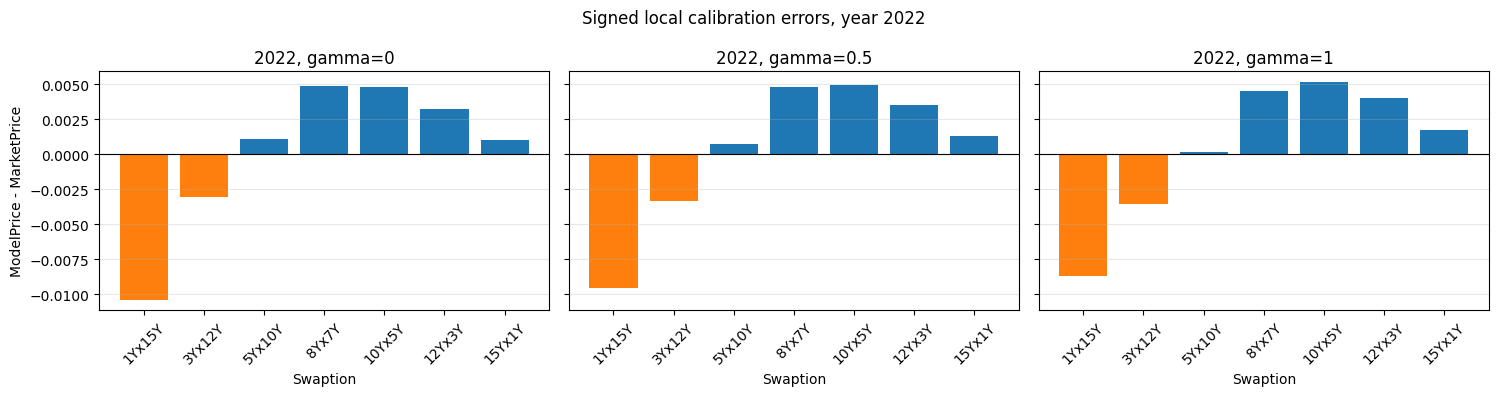

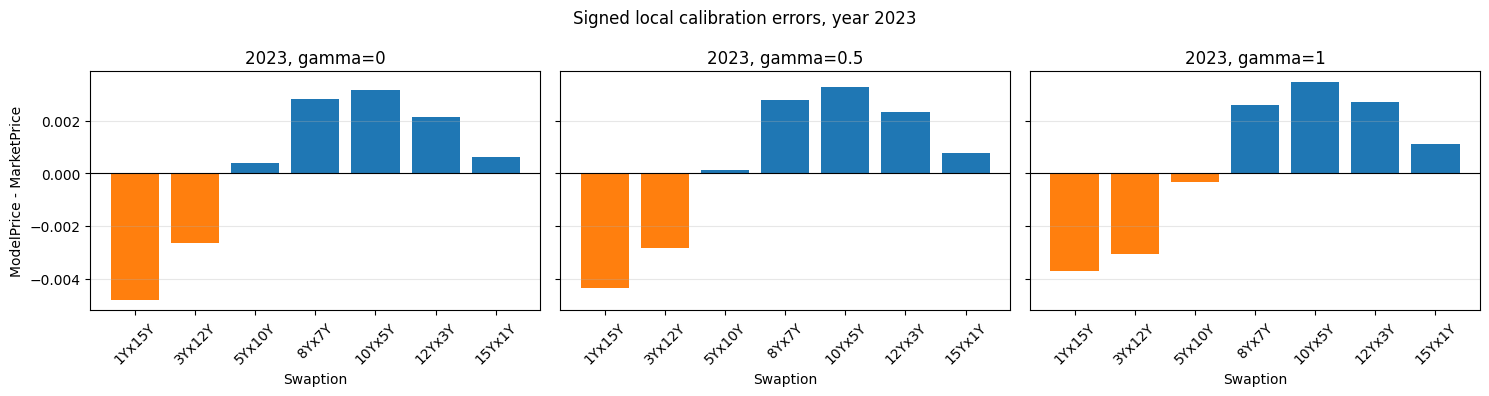

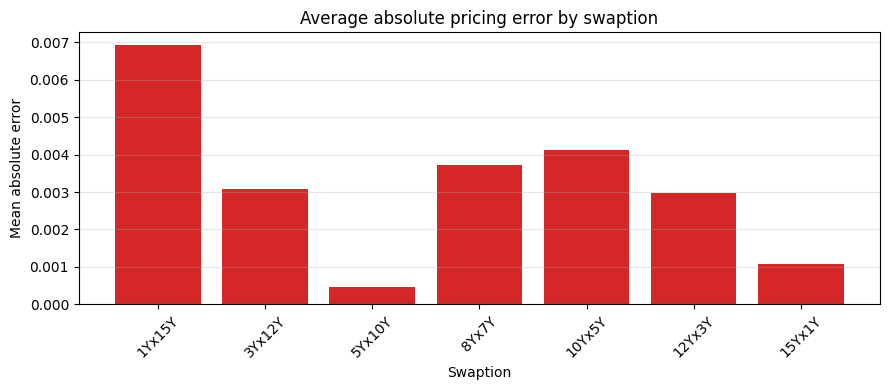

SSE contribution percentage by swaption


Swaption    1Yx15Y  3Yx12Y  5Yx10Y  8Yx7Y  10Yx5Y  12Yx3Y  15Yx1Y
Year Gamma                                                       
2022 0.0     61.01    5.33    0.68  13.40   13.09    5.91    0.59
     0.5     55.73    6.80    0.33  13.89   14.89    7.36    1.00
     1.0     49.00    8.15    0.02  13.29   17.21   10.41    1.92
2023 0.0     43.47   13.08    0.27  15.04   18.87    8.55    0.73
     0.5     36.78   15.69    0.03  15.02   20.90   10.41    1.18
     1.0     27.29   18.56    0.24  13.42   23.58   14.54    2.37

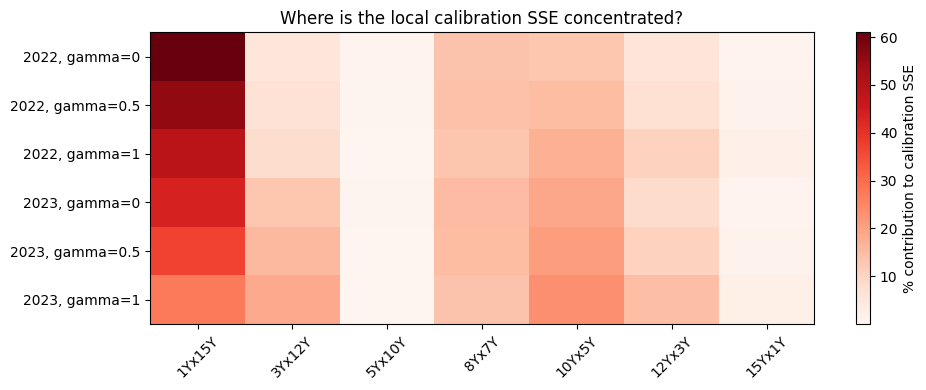

In [10]:
swaption_order = (
    local_error_df[["ExpiryYears", "TenorYears", "Swaption"]]
    .drop_duplicates()
    .sort_values("ExpiryYears")["Swaption"]
    .tolist()
)

# Signed pricing errors per calibration
for year in sorted(local_error_df["Year"].unique()):
    gammas_plot = sorted(local_error_df.loc[local_error_df["Year"] == year, "Gamma"].unique())

    fig, axes = plt.subplots(
        1,
        len(gammas_plot),
        figsize=(5 * len(gammas_plot), 4),
        sharey=True,
    )

    if len(gammas_plot) == 1:
        axes = [axes]

    for ax, gamma in zip(axes, gammas_plot):
        tmp = (
            local_error_df[
                (local_error_df["Year"] == year)
                & (local_error_df["Gamma"] == gamma)
            ]
            .set_index("Swaption")
            .reindex(swaption_order)
            .reset_index()
        )

        colors = np.where(tmp["SignedError"] >= 0, "tab:blue", "tab:orange")

        ax.bar(tmp["Swaption"], tmp["SignedError"], color=colors)
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_title(f"{year}, gamma={gamma:g}")
        ax.set_xlabel("Swaption")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("ModelPrice - MarketPrice")
    fig.suptitle(f"Signed local calibration errors, year {year}")
    fig.tight_layout()
    plt.show()

# Average absolute error by swaption across all local calibrations
mean_abs_by_swaption = (
    local_error_df
    .groupby("Swaption")["AbsError"]
    .mean()
    .reindex(swaption_order)
)

plt.figure(figsize=(9, 4))
plt.bar(mean_abs_by_swaption.index, mean_abs_by_swaption.values, color="tab:red")
plt.title("Average absolute pricing error by swaption")
plt.ylabel("Mean absolute error")
plt.xlabel("Swaption")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# SSE concentration table
sse_share_pivot = (
    local_error_df
    .pivot_table(
        index=["Year", "Gamma"],
        columns="Swaption",
        values="SSEContributionPct",
        aggfunc="sum",
    )
    .reindex(columns=swaption_order)
)

print("SSE contribution percentage by swaption")
display(sse_share_pivot.round(2))

plt.figure(figsize=(10, 4))
plt.imshow(sse_share_pivot.values, aspect="auto", cmap="Reds")
plt.colorbar(label="% contribution to calibration SSE")
plt.xticks(range(len(sse_share_pivot.columns)), sse_share_pivot.columns, rotation=45)
plt.yticks(
    range(len(sse_share_pivot.index)),
    [f"{y}, gamma={g:g}" for y, g in sse_share_pivot.index],
)
plt.title("Where is the local calibration SSE concentrated?")
plt.tight_layout()
plt.show()